### EDA on Main Application Table

In [55]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

In [56]:
# Display settings
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.4f}".format)

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [57]:
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    candidates = [start] + list(start.parents)

    for base in candidates:
        if (base / "data" / "raw" / "application_train.csv").exists():
            return base
        if (base / "application_train.csv").exists():
            return base

    return start

PROJECT_ROOT = find_project_root()

if (PROJECT_ROOT / "data" / "raw" / "application_train.csv").exists():
    DATA_DIR = PROJECT_ROOT / "data" / "raw"
    OUTPUT_DIR = PROJECT_ROOT / "outputs"
else:
    DATA_DIR = PROJECT_ROOT
    OUTPUT_DIR = PROJECT_ROOT / "outputs"

FIG_DIR = OUTPUT_DIR / "figures" / "02_main_table"
REPORT_DIR = OUTPUT_DIR / "reports"

FIG_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "application_train.csv"
TEST_PATH = DATA_DIR / "application_test.csv"
DESC_PATH = DATA_DIR / "HomeCredit_columns_description.csv"

SAVE_FIGURES = True

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TRAIN_PATH   :", TRAIN_PATH)
print("TEST_PATH    :", TEST_PATH)
print("DESC_PATH    :", DESC_PATH)
print("FIG_DIR      :", FIG_DIR)

PROJECT_ROOT: c:\Coding\Home-Credit-Default-Risk
TRAIN_PATH   : c:\Coding\Home-Credit-Default-Risk\data\raw\application_train.csv
TEST_PATH    : c:\Coding\Home-Credit-Default-Risk\data\raw\application_test.csv
DESC_PATH    : c:\Coding\Home-Credit-Default-Risk\data\raw\HomeCredit_columns_description.csv
FIG_DIR      : c:\Coding\Home-Credit-Default-Risk\outputs\figures\02_main_table


In [58]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

try:
    desc = pd.read_csv(DESC_PATH, encoding="latin1")
except Exception:
    desc = pd.read_csv(DESC_PATH, encoding_errors="ignore")

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Desc shape :", desc.shape)

Train shape: (307511, 122)
Test shape : (48744, 121)
Desc shape : (219, 5)


In [59]:
display(train.head())
display(test.head())
display(desc.head())

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,"202,500.0000","406,597.5000","24,700.5000","351,000.0000",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,"-3,648.0000",-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.0830,0.2629,0.1394,0.0247,0.0369,0.9722,0.6192,0.0143,0.0000,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0000,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.0000,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0000,2.0000,2.0000,2.0000,"-1,134.0000",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,"270,000.0000","1,293,502.5000","35,698.5000","1,129,500.0000",Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,"-1,186.0000",-291,NaN,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.3113,0.6222,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.0800,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0000,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.0800,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.0000","135,000.0000","6,750.0000","135,000.0000",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,"-4,260.0000",-2531,26.0000,1,1,1,1,1,0,Laborers,1.0000

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,"135,000.0000","568,800.0000","20,560.5000","450,000.0000",Unaccompanied,Working,Higher education,Married,House / apartment,0.0188,-19241,-2329,"-5,170.0000",-812,NaN,1,1,0,1,0,1,NaN,2.0000,2,2,TUESDAY,18,0,0,0,0,0,0,Kindergarten,0.7526,0.7897,0.1595,0.0660,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.1250,NaN,NaN,NaN,0.0505,NaN,NaN,0.0672,0.0612,0.9732,NaN,NaN,NaN,0.1379,0.1250,NaN,NaN,NaN,0.0526,NaN,NaN,0.0666,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.1250,NaN,NaN,NaN,0.0514,NaN,NaN,NaN,block of flats,0.0392,"Stone, brick",No,0.0000,0.0000,0.0000,0.0000,"-1,740.0000",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,100005,Cash loans,M,N,Y,0,"99,000.0000","222,768.0000","17,370.0000","180,000.0000",Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.0358,-18064,-4469,"-9,118.0000",-1623,NaN,1,1,0,1,0,0,Low-skill Laborers,2.0000,2,2,FRIDAY,9,0,0,0,0,0,0,Self-employed,0.5650,0.2917,0.4330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,3.0000
2,100013,Cash loans,M,Y,Y,0,"202,500.0000","663,264.0000","69,777.0000","630,000.0000",NaN,Working,Higher education,Married,House / apartment,0.0191,-20038,-4458,"-2,175.0000",-3503,5.0000,1,1,0,1,0,0,Drivers,2.0000,2,2,MONDAY,14,0,0,0,0,0,0,Transport: type 3,NaN,0.6998,0.6110,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,-856.0000,0,0,0,0,0,0,1,0,0,0,0

,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN


In [60]:
print("Does train contain TARGET? ->", "TARGET" in train.columns)
print("Does test contain TARGET?  ->", "TARGET" in test.columns)
print("Unique SK_ID_CURR in train:", train["SK_ID_CURR"].nunique())
print("Unique SK_ID_CURR in test :", test["SK_ID_CURR"].nunique())
print("Duplicated SK_ID_CURR in train:", train["SK_ID_CURR"].duplicated().sum())
print("Duplicated SK_ID_CURR in test :", test["SK_ID_CURR"].duplicated().sum())

Does train contain TARGET? -> True
Does test contain TARGET?  -> False
Unique SK_ID_CURR in train: 307511
Unique SK_ID_CURR in test : 48744
Duplicated SK_ID_CURR in train: 0
Duplicated SK_ID_CURR in test : 0


In [61]:
dtype_summary = pd.DataFrame({
    "column": train.columns,
    "dtype": train.dtypes.astype(str).values,
    "missing_count": train.isnull().sum().values,
    "missing_pct": (train.isnull().mean().values * 100)
}).sort_values(["dtype", "missing_pct"], ascending=[True, False])

display(dtype_summary.head(20))

print("Number of columns in train:", train.shape[1])
print("Numeric columns:", train.select_dtypes(include=[np.number]).shape[1])
print("Object columns :", train.select_dtypes(include=["object"]).shape[1])

,column,dtype,missing_count,missing_pct
48,COMMONAREA_AVG,float64,214865,69.8723
62,COMMONAREA_MODE,float64,214865,69.8723
76,COMMONAREA_MEDI,float64,214865,69.8723
56,NONLIVINGAPARTMENTS_AVG,float64,213514,69.4330
70,NONLIVINGAPARTMENTS_MODE,float64,213514,69.4330
84,NONLIVINGAPARTMENTS_MEDI,float64,213514,69.4330
54,LIVINGAPARTMENTS_AVG,float64,210199,68.3550
68,LIVINGAPARTMENTS_MODE,float64,210199,68.3550
82,LIVINGAPARTMENTS_MEDI,float64,210199,68.3550
52,FLOORSMIN_AVG,float64,208642,67.8486


Number of columns in train: 122
Numeric columns: 106
Object columns : 16


### 1. Target Distribution

In [62]:
target_counts = train["TARGET"].value_counts().sort_index()
target_props = train["TARGET"].value_counts(normalize=True).sort_index()

print("Target counts:")
display(target_counts)

print("Target proportions:")
display(target_props)

Target counts:


TARGET
0    282686
1     24825
Name: count, dtype: int64

Target proportions:


TARGET
0   0.9193
1   0.0807
Name: proportion, dtype: float64

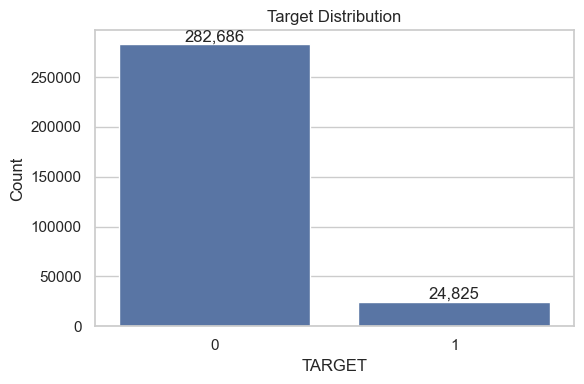

In [63]:
def savefig(filename):
    if SAVE_FIGURES:
        plt.savefig(FIG_DIR / filename, dpi=150, bbox_inches="tight")

plt.figure(figsize=(6, 4))
ax = sns.countplot(x="TARGET", data=train)
plt.title("Target Distribution")
plt.xlabel("TARGET")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
savefig("target_distribution.png")
plt.show()

### 2. Column Groups

In [64]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train.select_dtypes(include=["object"]).columns.tolist()

binary_like_cols = [
    col for col in train.columns
    if train[col].nunique(dropna=False) <= 2
]

column_group_summary = pd.DataFrame({
    "group": ["numeric", "categorical", "binary_like"],
    "n_columns": [len(numeric_cols), len(categorical_cols), len(binary_like_cols)],
    "example_columns": [
        ", ".join(numeric_cols[:10]),
        ", ".join(categorical_cols[:10]),
        ", ".join(binary_like_cols[:10]),
    ]
})

display(column_group_summary)

,group,n_columns,example_columns
0,numeric,106,"SK_ID_CURR, TARGET, CNT_CHILDREN, AMT_INCOME_T..."
1,categorical,16,"NAME_CONTRACT_TYPE, CODE_GENDER, FLAG_OWN_CAR,..."
2,binary_like,36,"TARGET, NAME_CONTRACT_TYPE, FLAG_OWN_CAR, FLAG..."


### 3. Missing Value Analysis

In [65]:
missing_train = pd.DataFrame({
    "column": train.columns,
    "missing_count": train.isnull().sum().values,
    "missing_pct": (train.isnull().mean().values * 100),
    "dtype": train.dtypes.astype(str).values,
}).sort_values("missing_pct", ascending=False)

missing_test = pd.DataFrame({
    "column": test.columns,
    "missing_count": test.isnull().sum().values,
    "missing_pct": (test.isnull().mean().values * 100),
    "dtype": test.dtypes.astype(str).values,
}).sort_values("missing_pct", ascending=False)

display(missing_train.head(20))

,column,missing_count,missing_pct,dtype
76,COMMONAREA_MEDI,214865,69.8723,float64
48,COMMONAREA_AVG,214865,69.8723,float64
62,COMMONAREA_MODE,214865,69.8723,float64
70,NONLIVINGAPARTMENTS_MODE,213514,69.4330,float64
56,NONLIVINGAPARTMENTS_AVG,213514,69.4330,float64
84,NONLIVINGAPARTMENTS_MEDI,213514,69.4330,float64
86,FONDKAPREMONT_MODE,210295,68.3862,object
68,LIVINGAPARTMENTS_MODE,210199,68.3550,float64
54,LIVINGAPARTMENTS_AVG,210199,68.3550,float64
82,LIVINGAPARTMENTS_MEDI,210199,68.3550,float64


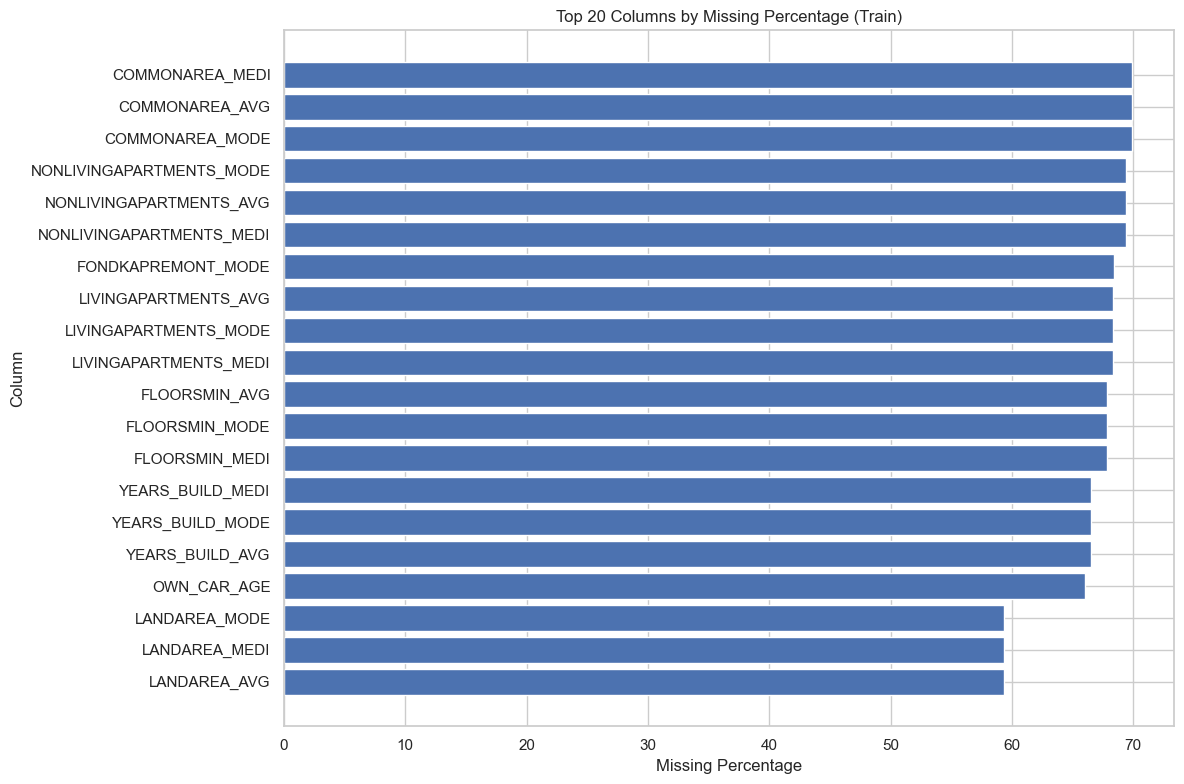

In [66]:
top_missing = missing_train.head(20).sort_values("missing_pct", ascending=True)

plt.figure(figsize=(12, 8))
plt.barh(top_missing["column"], top_missing["missing_pct"])
plt.title("Top 20 Columns by Missing Percentage (Train)")
plt.xlabel("Missing Percentage")
plt.ylabel("Column")
plt.tight_layout()
savefig("top20_missing_columns_train.png")
plt.show()

In [67]:
missing_compare = (
    missing_train[["column", "missing_pct"]]
    .merge(
        missing_test[["column", "missing_pct"]],
        on="column",
        how="left",
        suffixes=("_train", "_test")
    )
)

missing_compare["diff_pct"] = missing_compare["missing_pct_train"] - missing_compare["missing_pct_test"]
display(missing_compare.sort_values("missing_pct_train", ascending=False).head(20))

,column,missing_pct_train,missing_pct_test,diff_pct
0,COMMONAREA_MEDI,69.8723,68.7161,1.1561
2,COMMONAREA_MODE,69.8723,68.7161,1.1561
1,COMMONAREA_AVG,69.8723,68.7161,1.1561
3,NONLIVINGAPARTMENTS_MODE,69.4330,68.4125,1.0204
5,NONLIVINGAPARTMENTS_MEDI,69.4330,68.4125,1.0204
4,NONLIVINGAPARTMENTS_AVG,69.4330,68.4125,1.0204
6,FONDKAPREMONT_MODE,68.3862,67.2842,1.1020
8,LIVINGAPARTMENTS_AVG,68.3550,67.2493,1.1057
9,LIVINGAPARTMENTS_MEDI,68.3550,67.2493,1.1057
7,LIVINGAPARTMENTS_MODE,68.3550,67.2493,1.1057


### 4. Important Numeric Variables

In [68]:
key_num_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
]

display(train[key_num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,"307,511.0000","168,797.9193","237,123.1463","25,650.0000","112,500.0000","147,150.0000","202,500.0000","117,000,000.0000"
AMT_CREDIT,"307,511.0000","599,025.9997","402,490.7770","45,000.0000","270,000.0000","513,531.0000","808,650.0000","4,050,000.0000"
AMT_ANNUITY,"307,499.0000","27,108.5739","14,493.7373","1,615.5000","16,524.0000","24,903.0000","34,596.0000","258,025.5000"
DAYS_BIRTH,"307,511.0000","-16,036.9951","4,363.9886","-25,229.0000","-19,682.0000","-15,750.0000","-12,413.0000","-7,489.0000"
DAYS_EMPLOYED,"307,511.0000","63,815.0459","141,275.7665","-17,912.0000","-2,760.0000","-1,213.0000",-289.0000,"365,243.0000"


In [69]:
# Create interpretable versions
train["AGE_YEARS"] = -train["DAYS_BIRTH"] / 365
test["AGE_YEARS"] = -test["DAYS_BIRTH"] / 365

train["EMPLOYED_YEARS"] = -train["DAYS_EMPLOYED"] / 365
test["EMPLOYED_YEARS"] = -test["DAYS_EMPLOYED"] / 365

In [70]:
def clean_series(s):
    s = s.replace([np.inf, -np.inf], np.nan)
    return s.dropna()

def clipped_series(s, lower=0.01, upper=0.99):
    s = clean_series(s)
    if s.empty:
        return s
    lo = s.quantile(lower)
    hi = s.quantile(upper)
    return s.clip(lo, hi)

def plot_hist_and_box(df, col, filename=None, clip_quantiles=None):
    series = df[col]
    series = clean_series(series)

    if clip_quantiles is not None and not series.empty:
        lo, hi = clip_quantiles
        series = series.clip(series.quantile(lo), series.quantile(hi))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(series, kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")
    sns.boxplot(x=series, ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")
    plt.tight_layout()
    if filename:
        savefig(filename)
    plt.show()

def plot_box_by_target(df, col, filename=None, clip_quantiles=None):
    temp = df[[col, "TARGET"]].copy()
    temp[col] = temp[col].replace([np.inf, -np.inf], np.nan)
    temp = temp.dropna()

    if clip_quantiles is not None and not temp.empty:
        lo, hi = clip_quantiles
        q_low = temp[col].quantile(lo)
        q_high = temp[col].quantile(hi)
        temp[col] = temp[col].clip(q_low, q_high)

    plt.figure(figsize=(8, 5))
    sns.boxplot(data=temp, x="TARGET", y=col)
    plt.title(f"{col} by TARGET")
    plt.tight_layout()
    if filename:
        savefig(filename)
    plt.show()

def plot_default_rate_by_bin(df, col, q=10, filename=None):
    temp = df[[col, "TARGET"]].copy()
    temp[col] = temp[col].replace([np.inf, -np.inf], np.nan)
    temp = temp.dropna()

    if temp[col].nunique() < 3:
        print(f"Skipped {col}: too few unique values for qcut.")
        return

    try:
        temp["bin"] = pd.qcut(temp[col], q=q, duplicates="drop")
    except ValueError:
        print(f"Skipped {col}: qcut failed.")
        return

    rate = temp.groupby("bin", observed=False)["TARGET"].mean().reset_index()

    plt.figure(figsize=(12, 5))
    sns.barplot(data=rate, x="bin", y="TARGET")
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Default Rate by {col} Quantile Bin")
    plt.ylabel("Mean TARGET")
    plt.xlabel(col)
    plt.tight_layout()
    if filename:
        savefig(filename)
    plt.show()

def plot_default_rate_by_category(df, col, top_n=10, filename=None):
    temp = df[[col, "TARGET"]].copy()
    temp[col] = temp[col].fillna("MISSING").astype(str)

    top_categories = temp[col].value_counts().head(top_n).index
    temp = temp[temp[col].isin(top_categories)]

    rate = (
        temp.groupby(col, dropna=False)["TARGET"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(data=rate, x=col, y="TARGET")
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Default Rate by {col}")
    plt.ylabel("Mean TARGET")
    plt.tight_layout()
    if filename:
        savefig(filename)
    plt.show()

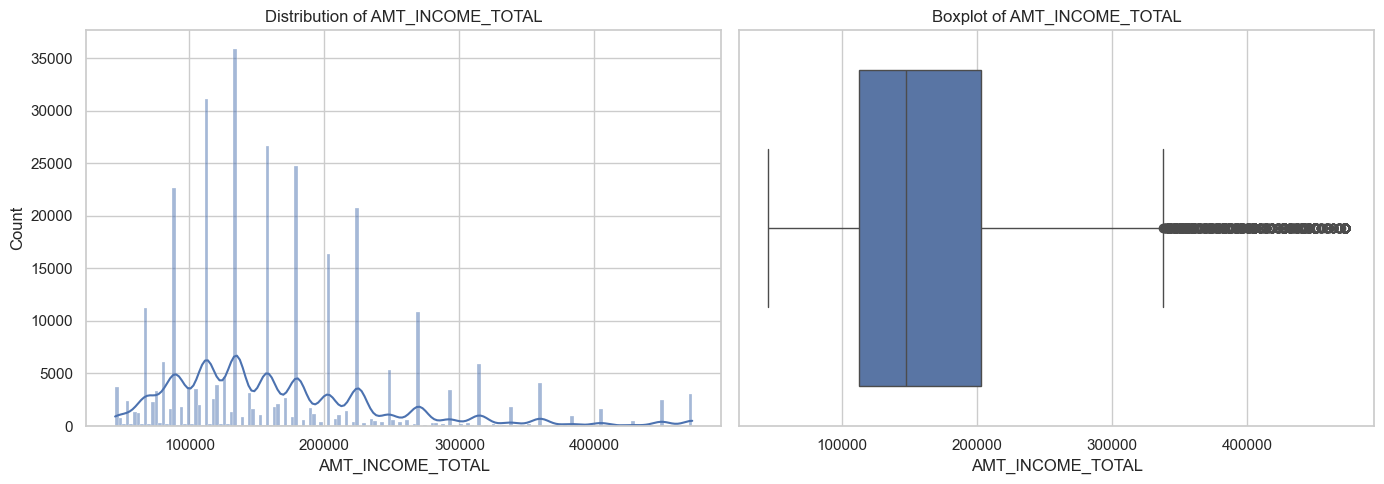

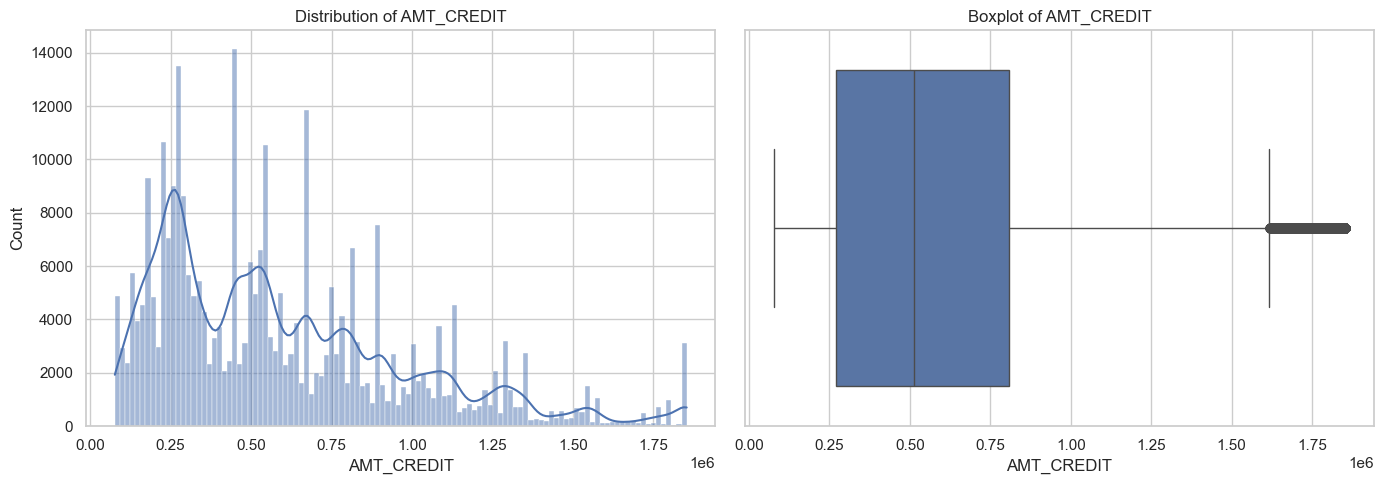

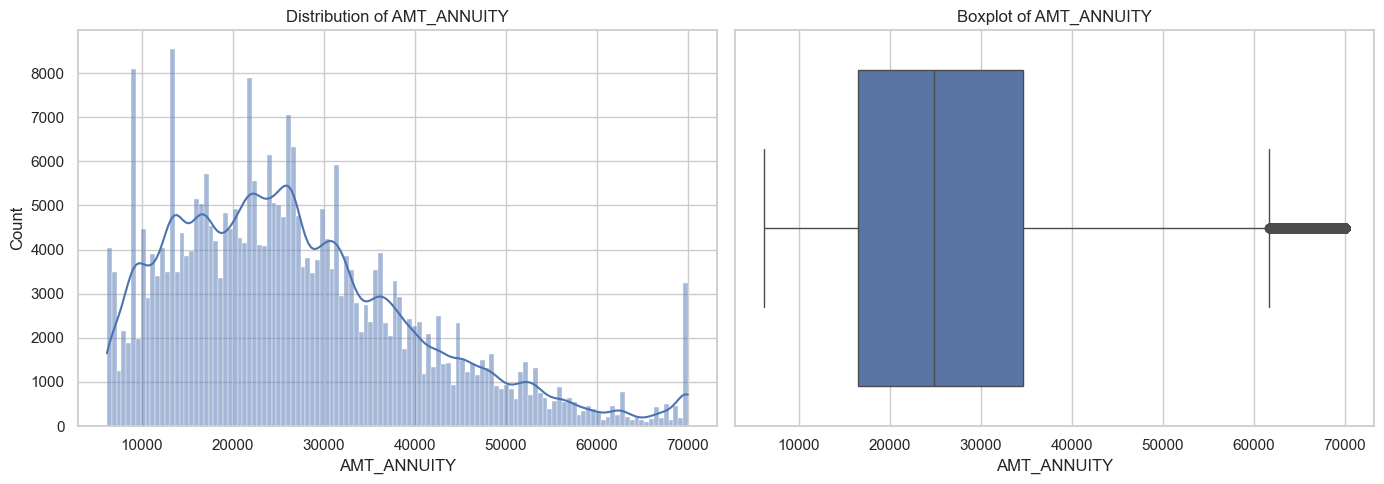

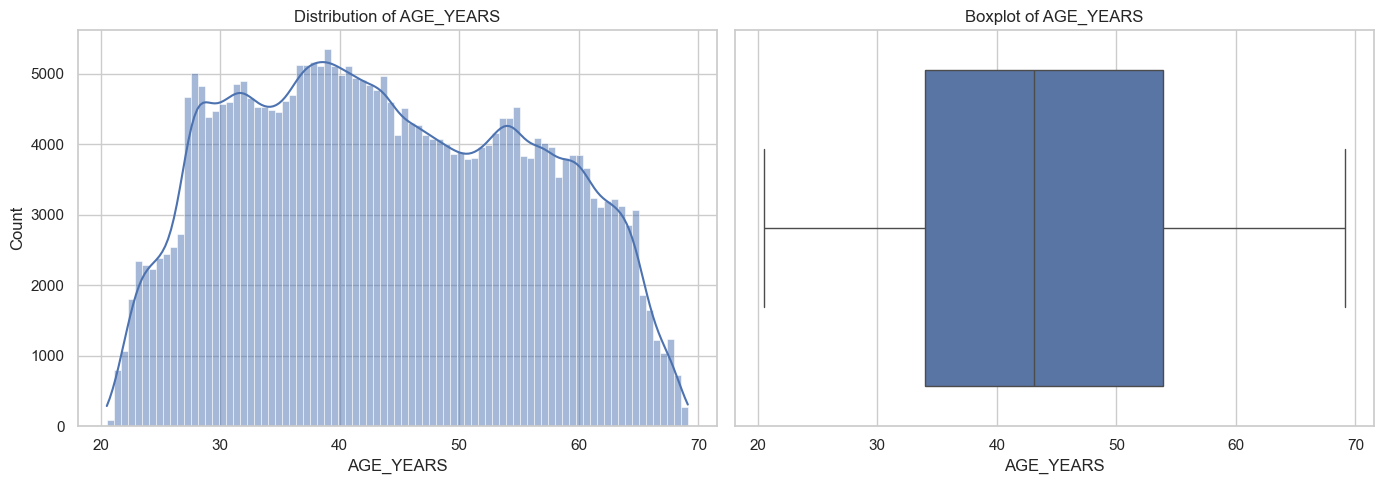

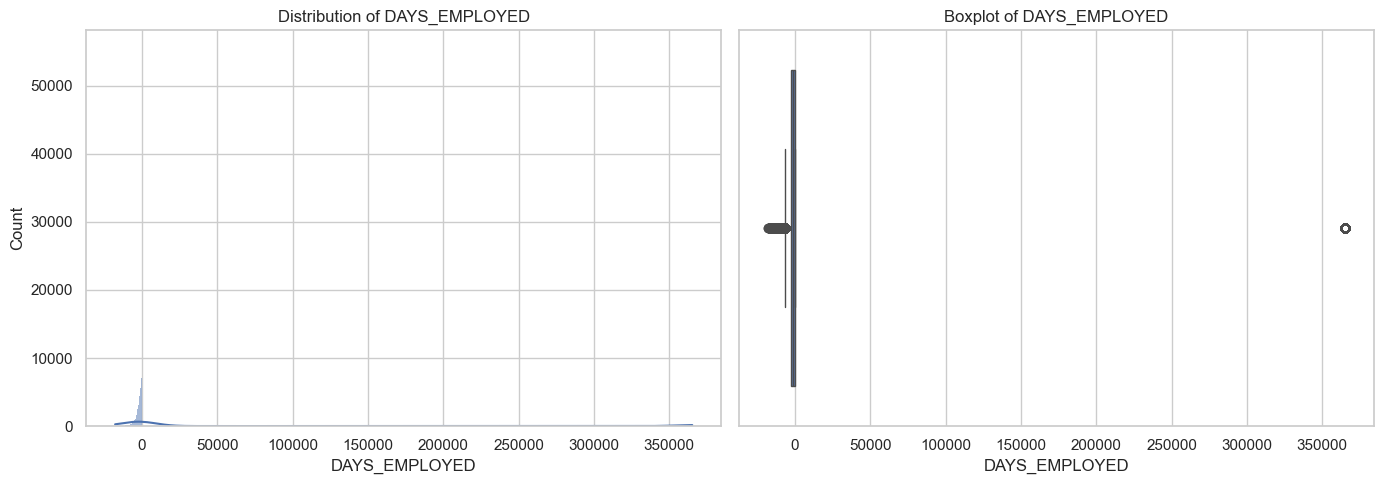

In [71]:
plot_hist_and_box(train, "AMT_INCOME_TOTAL", "amt_income_total_dist.png", clip_quantiles=(0.01, 0.99))
plot_hist_and_box(train, "AMT_CREDIT", "amt_credit_dist.png", clip_quantiles=(0.01, 0.99))
plot_hist_and_box(train, "AMT_ANNUITY", "amt_annuity_dist.png", clip_quantiles=(0.01, 0.99))
plot_hist_and_box(train, "AGE_YEARS", "age_years_dist.png")
plot_hist_and_box(train, "DAYS_EMPLOYED", "days_employed_dist_raw.png")

### 5. Relationship Between Core Variables and TARGET

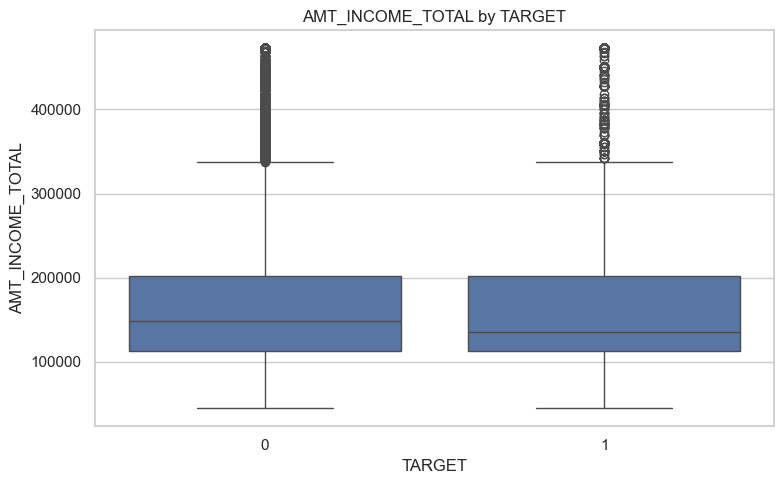

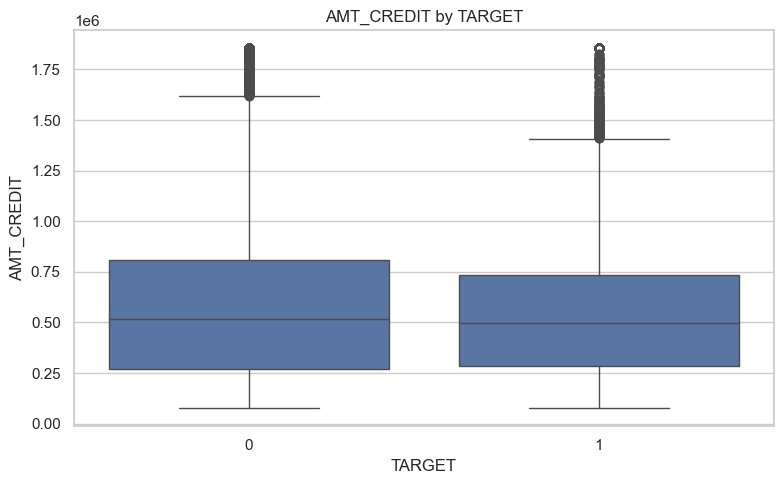

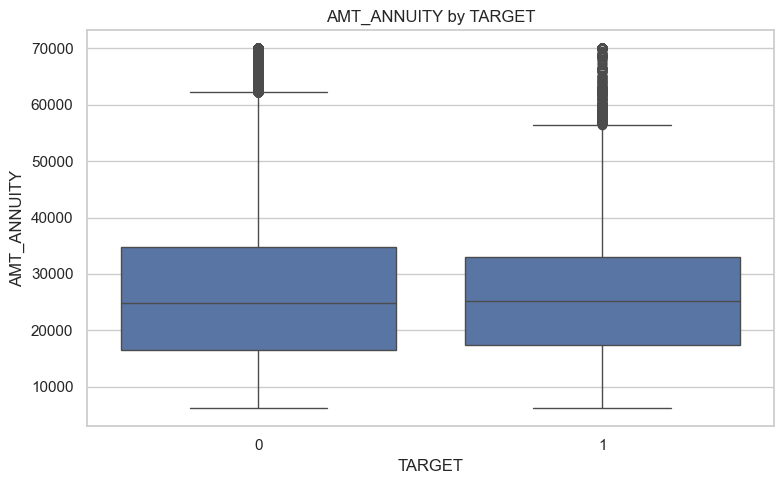

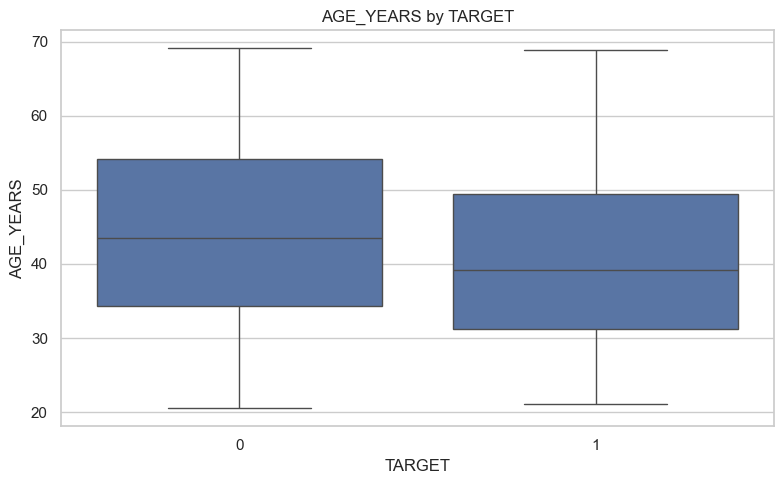

In [72]:
plot_box_by_target(train, "AMT_INCOME_TOTAL", "amt_income_total_by_target.png", clip_quantiles=(0.01, 0.99))
plot_box_by_target(train, "AMT_CREDIT", "amt_credit_by_target.png", clip_quantiles=(0.01, 0.99))
plot_box_by_target(train, "AMT_ANNUITY", "amt_annuity_by_target.png", clip_quantiles=(0.01, 0.99))
plot_box_by_target(train, "AGE_YEARS", "age_years_by_target.png")

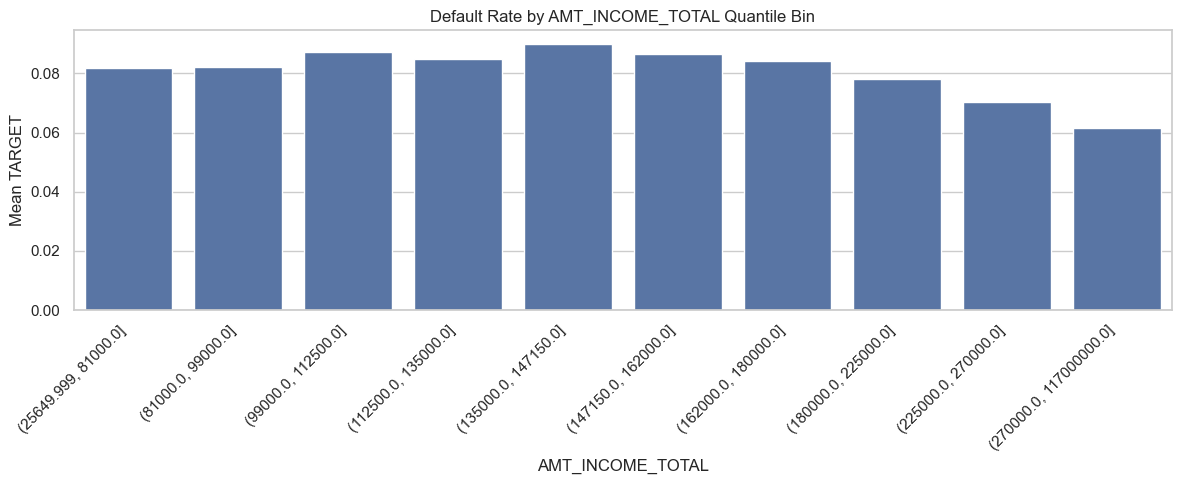

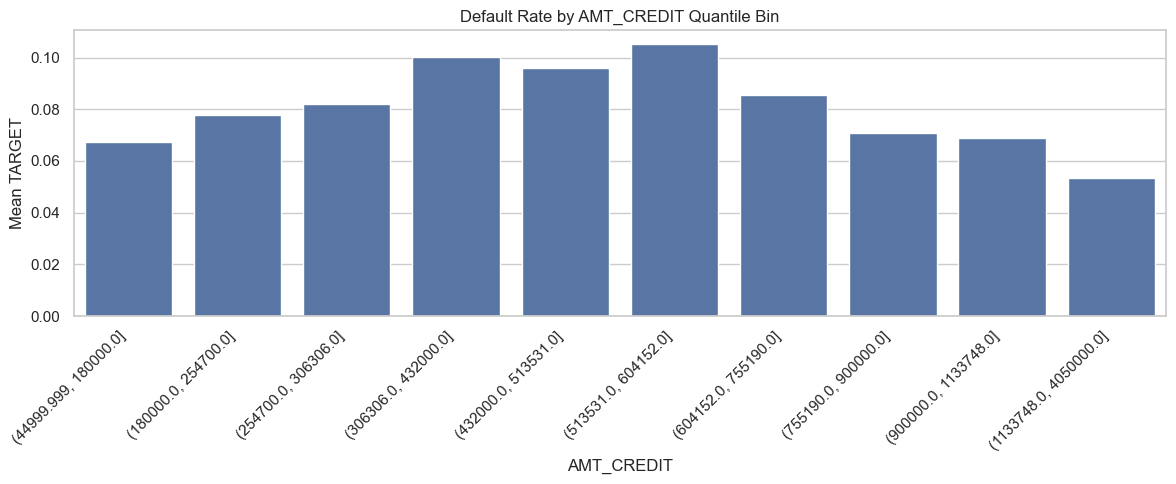

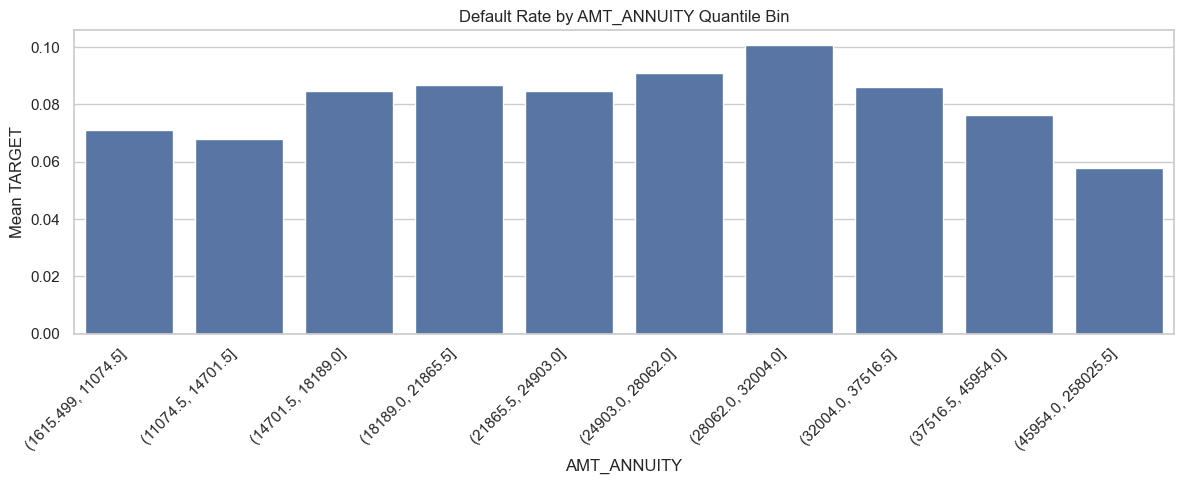

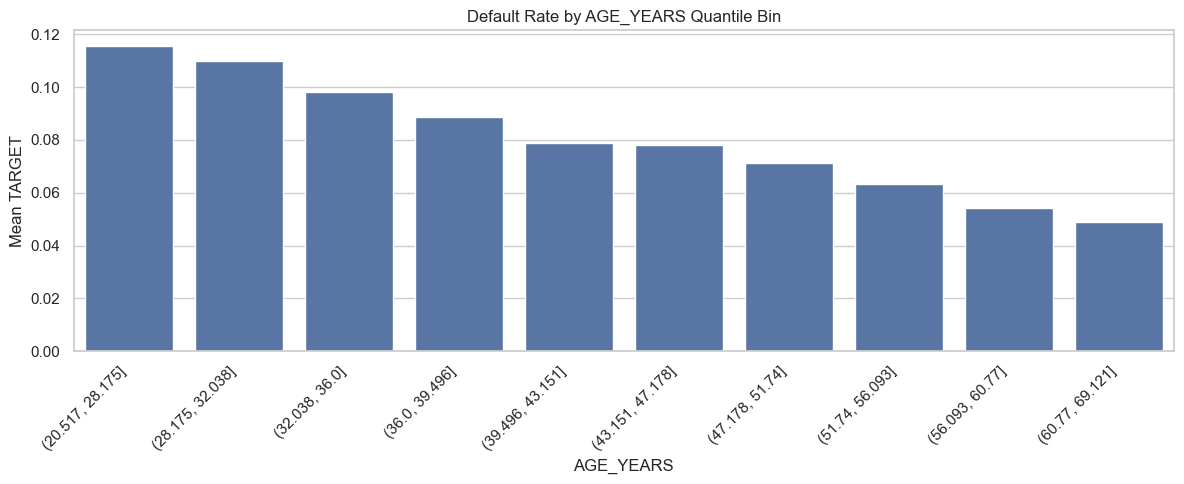

In [73]:
plot_default_rate_by_bin(train, "AMT_INCOME_TOTAL", q=10, filename="default_rate_by_income_bin.png")
plot_default_rate_by_bin(train, "AMT_CREDIT", q=10, filename="default_rate_by_credit_bin.png")
plot_default_rate_by_bin(train, "AMT_ANNUITY", q=10, filename="default_rate_by_annuity_bin.png")
plot_default_rate_by_bin(train, "AGE_YEARS", q=10, filename="default_rate_by_age_bin.png")

### 6. DAYS_EMPLOYED Anomaly Check

In [74]:
display(train["DAYS_EMPLOYED"].describe())
display(train["DAYS_EMPLOYED"].value_counts().head(10))

count   307,511.0000
mean     63,815.0459
std     141,275.7665
min     -17,912.0000
25%      -2,760.0000
50%      -1,213.0000
75%        -289.0000
max     365,243.0000
Name: DAYS_EMPLOYED, dtype: float64

DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-230         151
-199         151
-212         150
-384         143
-229         143
-231         140
-215         138
Name: count, dtype: int64

In [75]:
anomaly_value = 365243

train["DAYS_EMPLOYED_ANOM"] = (train["DAYS_EMPLOYED"] == anomaly_value).astype(int)
test["DAYS_EMPLOYED_ANOM"] = (test["DAYS_EMPLOYED"] == anomaly_value).astype(int)

print("Anomalous rows in train:", train["DAYS_EMPLOYED_ANOM"].sum())
print("Anomalous rows in test :", test["DAYS_EMPLOYED_ANOM"].sum())
print("Anomalous percentage in train:", round(train["DAYS_EMPLOYED_ANOM"].mean() * 100, 4))
print("Anomalous percentage in test :", round(test["DAYS_EMPLOYED_ANOM"].mean() * 100, 4))

display(train.groupby("DAYS_EMPLOYED_ANOM")["TARGET"].agg(["count", "mean"]))

Anomalous rows in train: 55374
Anomalous rows in test : 9274
Anomalous percentage in train: 18.0072
Anomalous percentage in test : 19.0259


,count,mean
DAYS_EMPLOYED_ANOM,,
0,252137,0.0866
1,55374,0.0540


In [76]:
train["DAYS_EMPLOYED_CLEAN"] = train["DAYS_EMPLOYED"].replace(anomaly_value, np.nan)
test["DAYS_EMPLOYED_CLEAN"] = test["DAYS_EMPLOYED"].replace(anomaly_value, np.nan)

train["EMPLOYED_YEARS_CLEAN"] = -train["DAYS_EMPLOYED_CLEAN"] / 365
test["EMPLOYED_YEARS_CLEAN"] = -test["DAYS_EMPLOYED_CLEAN"] / 365

display(train[["DAYS_EMPLOYED", "DAYS_EMPLOYED_CLEAN", "EMPLOYED_YEARS_CLEAN"]].head())

,DAYS_EMPLOYED,DAYS_EMPLOYED_CLEAN,EMPLOYED_YEARS_CLEAN
0,-637,-637.0000,1.7452
1,-1188,"-1,188.0000",3.2548
2,-225,-225.0000,0.6164
3,-3039,"-3,039.0000",8.3260
4,-3038,"-3,038.0000",8.3233


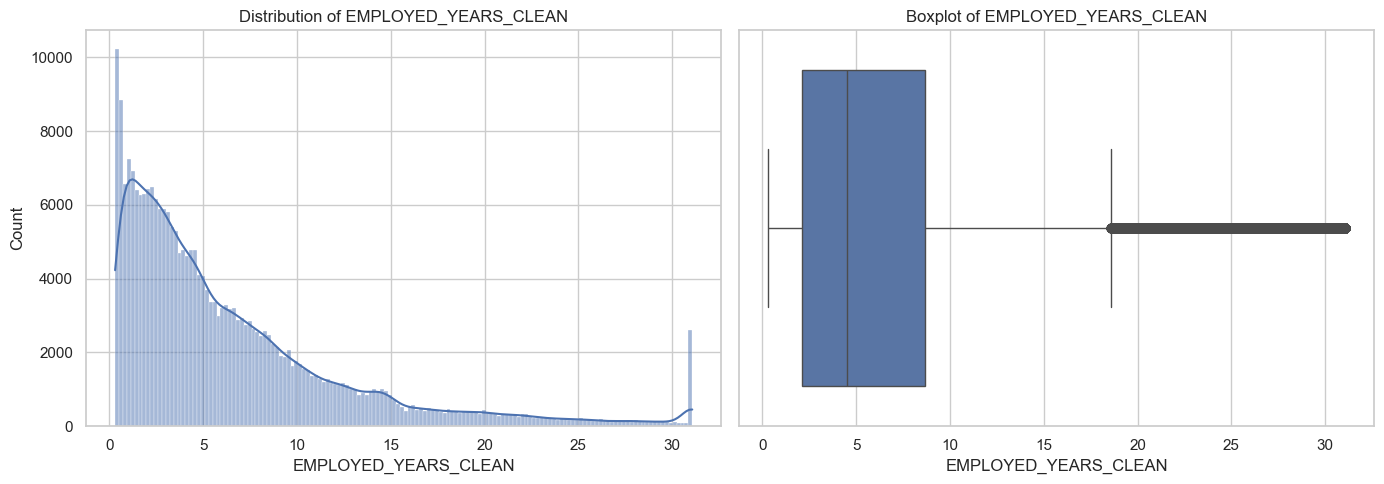

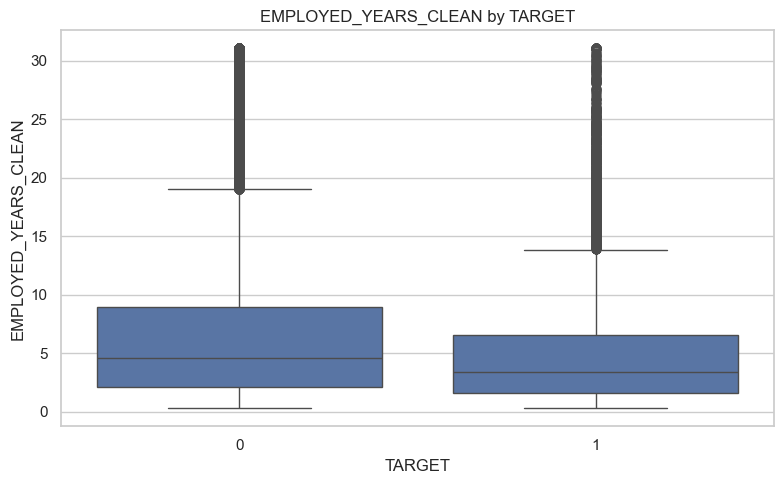

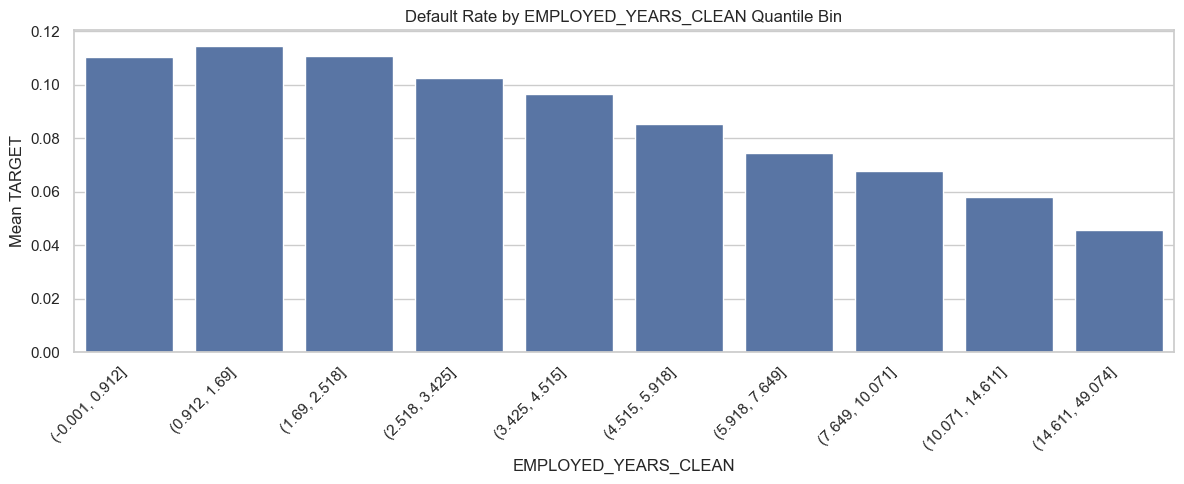

In [77]:
plot_hist_and_box(train, "EMPLOYED_YEARS_CLEAN", "employed_years_clean_dist.png", clip_quantiles=(0.01, 0.99))
plot_box_by_target(train, "EMPLOYED_YEARS_CLEAN", "employed_years_clean_by_target.png", clip_quantiles=(0.01, 0.99))
plot_default_rate_by_bin(train, "EMPLOYED_YEARS_CLEAN", q=10, filename="default_rate_by_employed_years_bin.png")

### 7. Simple Ratio Features

In [78]:
def safe_divide(numerator, denominator):
    denominator = denominator.replace(0, np.nan)
    return numerator / denominator

for df in [train, test]:
    df["INCOME_CREDIT_RATIO"] = safe_divide(df["AMT_INCOME_TOTAL"], df["AMT_CREDIT"])
    df["ANNUITY_INCOME_RATIO"] = safe_divide(df["AMT_ANNUITY"], df["AMT_INCOME_TOTAL"])
    df["CREDIT_GOODS_RATIO"] = safe_divide(df["AMT_CREDIT"], df["AMT_GOODS_PRICE"])
    df["EMPLOYMENT_AGE_RATIO"] = (-df["DAYS_EMPLOYED_CLEAN"]) / (-df["DAYS_BIRTH"])

In [79]:
ratio_cols = [
    "INCOME_CREDIT_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_GOODS_RATIO",
    "EMPLOYMENT_AGE_RATIO",
]

display(train[ratio_cols].replace([np.inf, -np.inf], np.nan).describe().T)

,count,mean,std,min,25%,50%,75%,max
INCOME_CREDIT_RATIO,"307,511.0000",0.3997,0.5079,0.0118,0.1938,0.3063,0.4954,208.0033
ANNUITY_INCOME_RATIO,"307,499.0000",0.1809,0.0946,0.0002,0.1148,0.1628,0.2291,1.8760
CREDIT_GOODS_RATIO,"307,233.0000",1.1230,0.1240,0.1500,1.0000,1.1188,1.1980,6.0000
EMPLOYMENT_AGE_RATIO,"252,137.0000",0.1569,0.1335,-0.0000,0.0561,0.1187,0.2192,0.7288


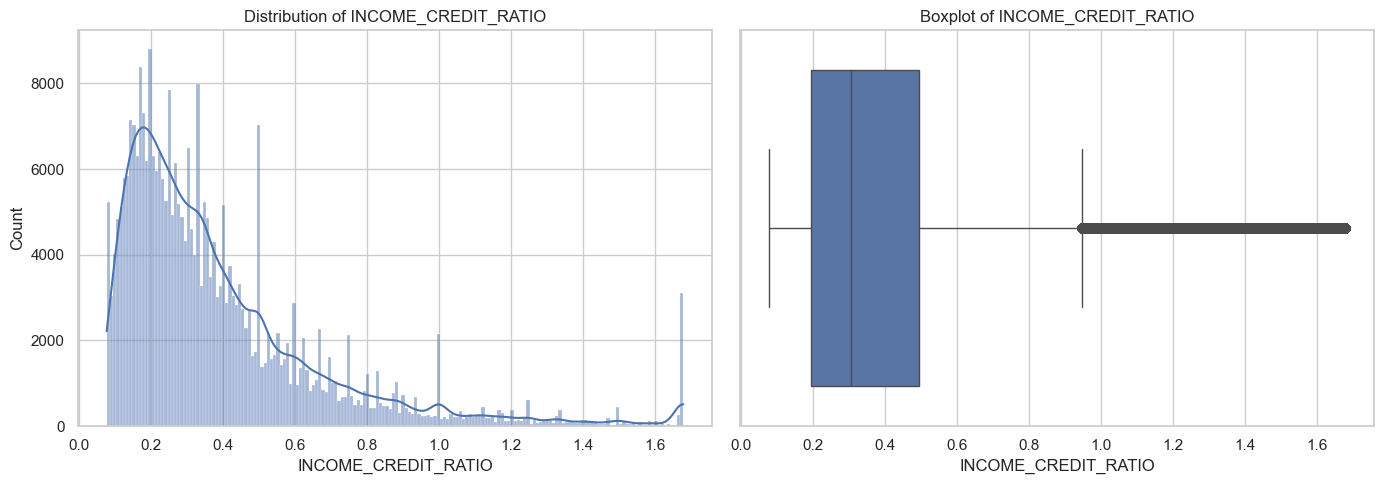

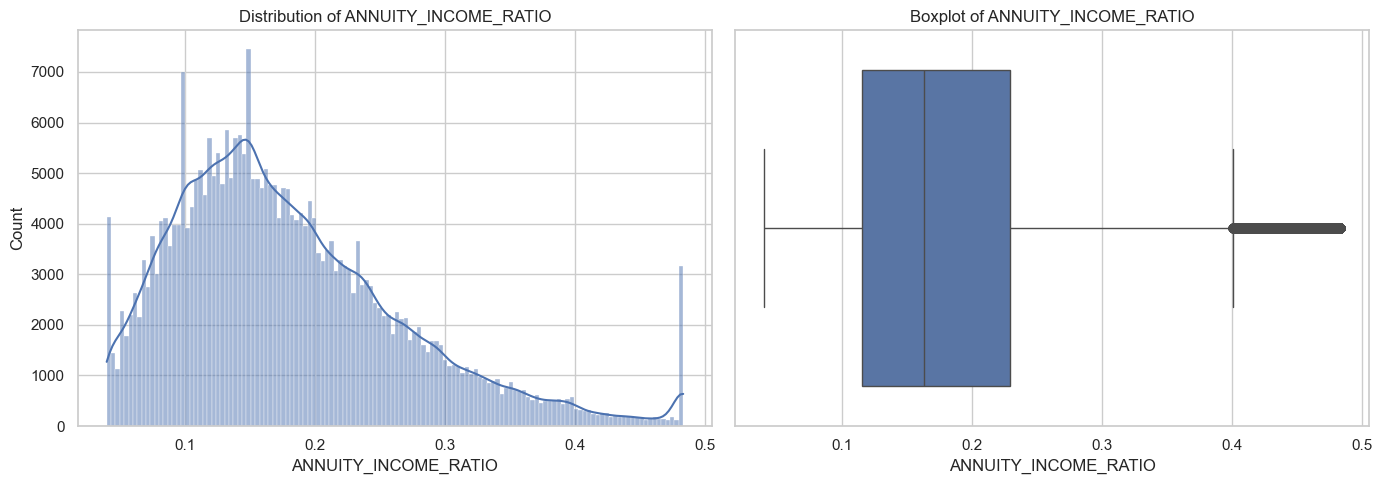

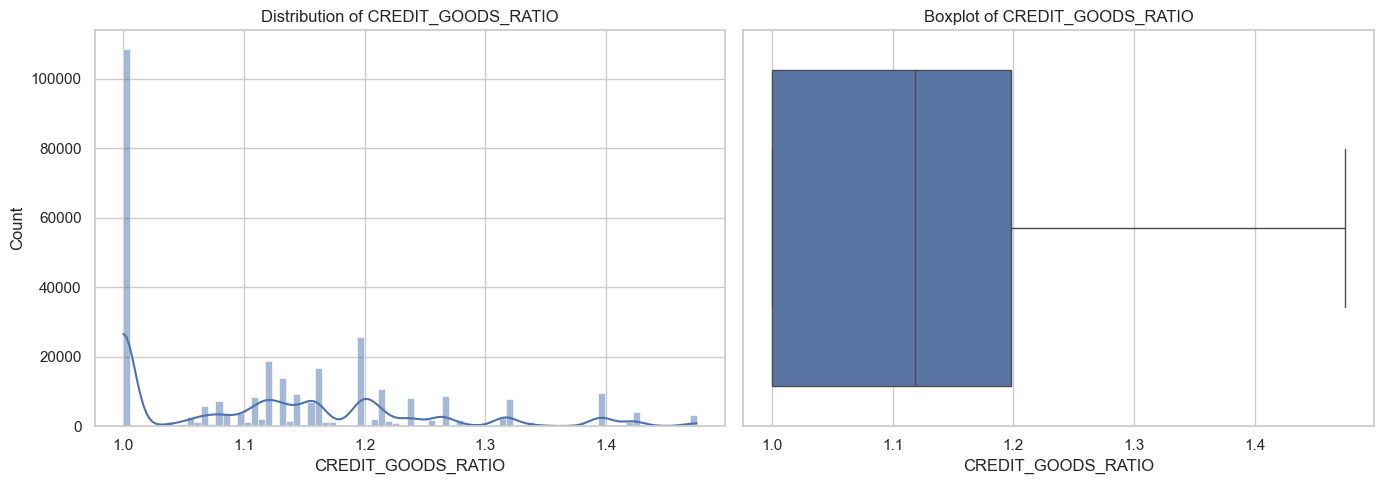

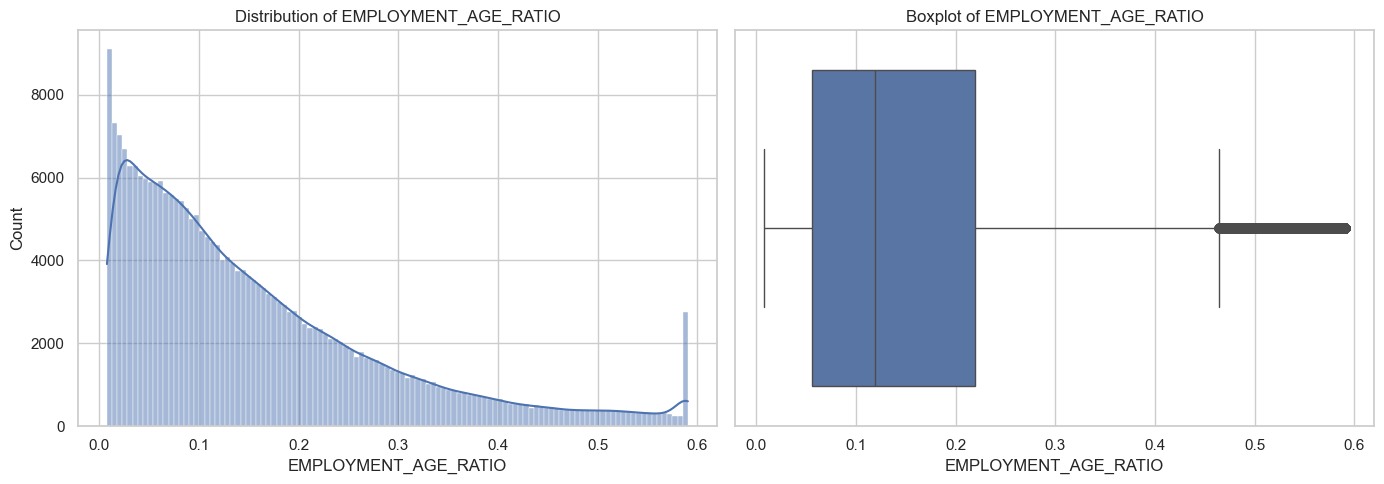

In [80]:
for col in ratio_cols:
    plot_hist_and_box(train, col, f"{col.lower()}_dist.png", clip_quantiles=(0.01, 0.99))

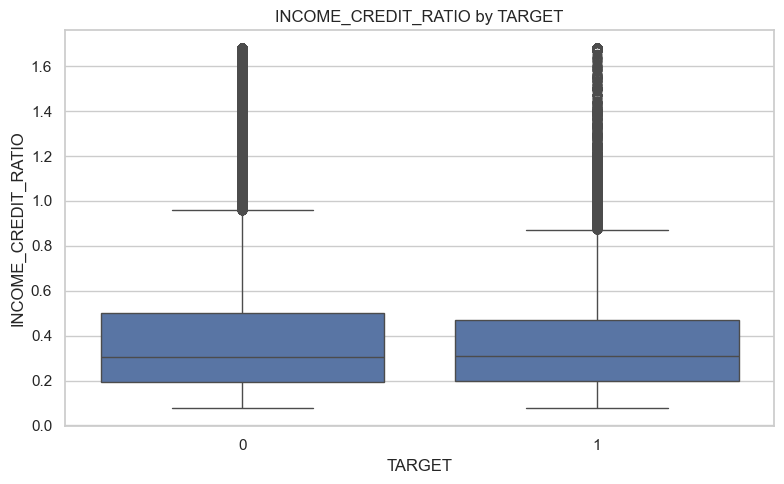

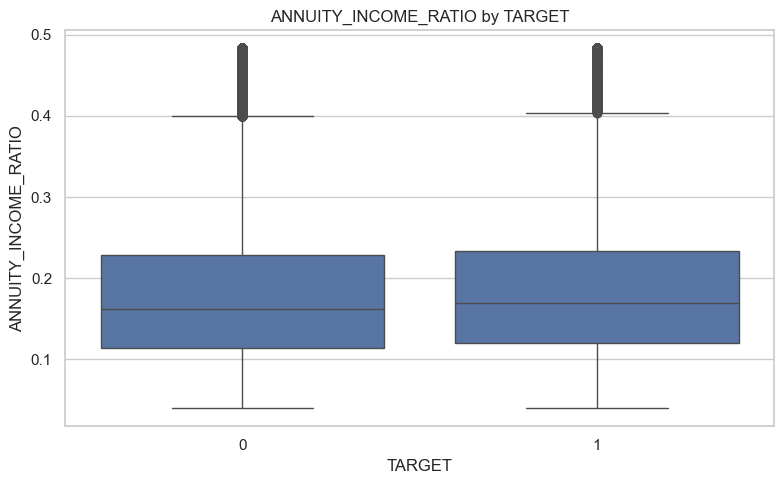

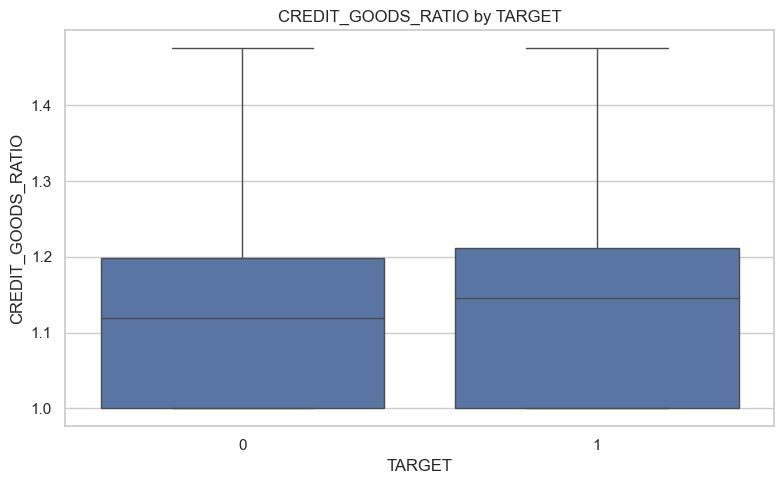

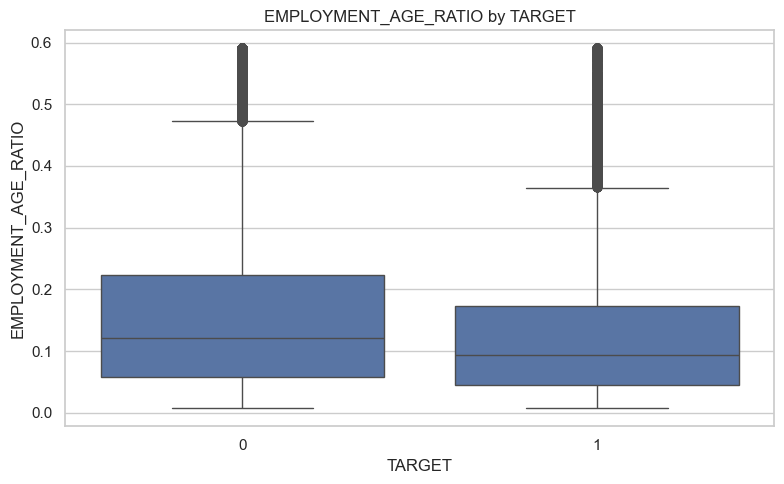

In [81]:
for col in ratio_cols:
    plot_box_by_target(train, col, f"{col.lower()}_by_target.png", clip_quantiles=(0.01, 0.99))

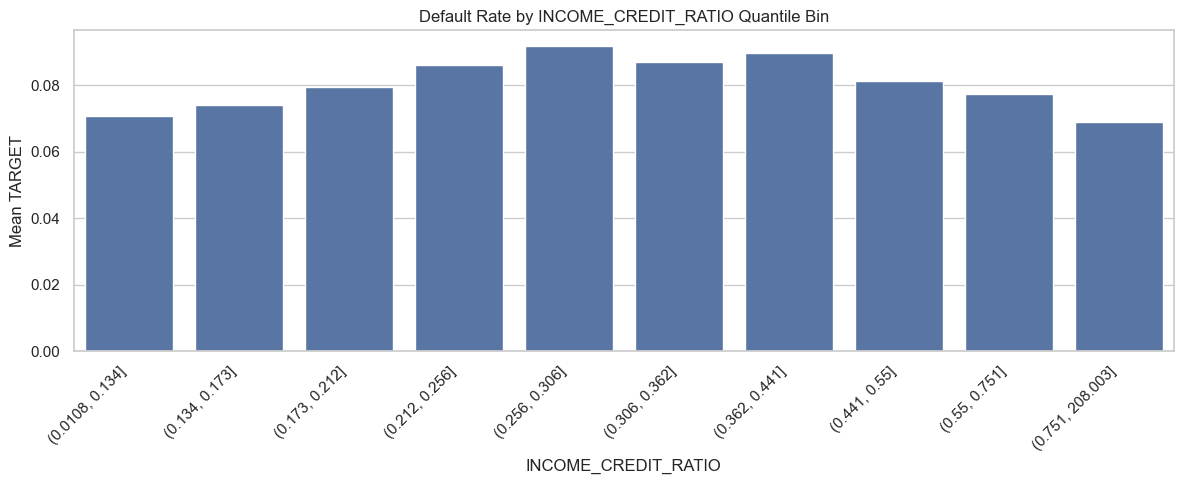

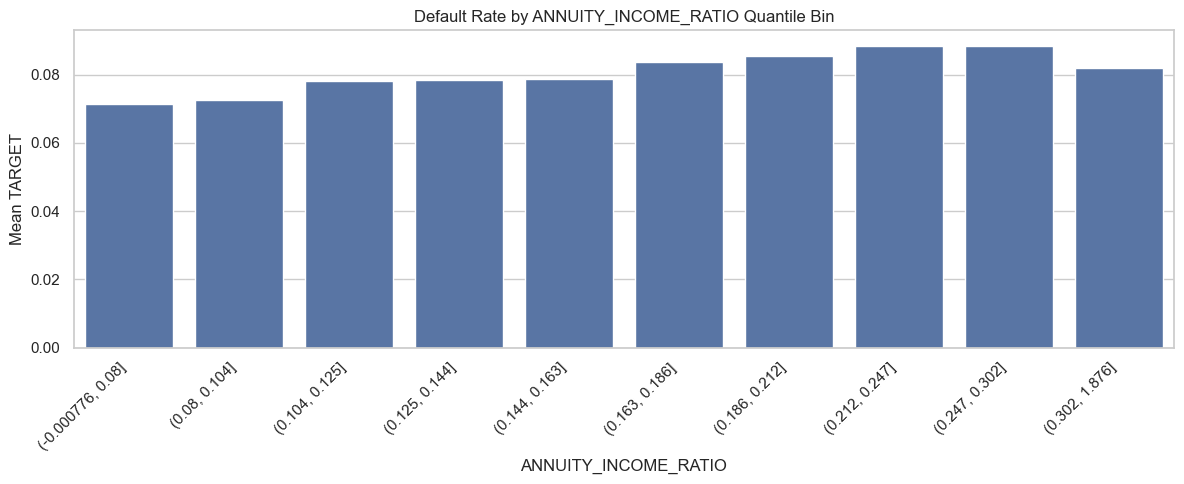

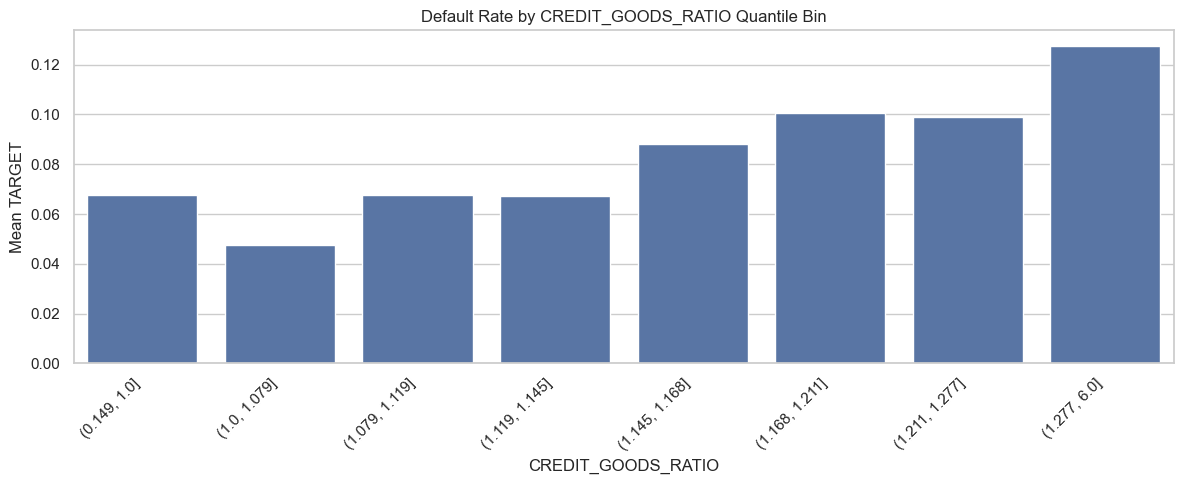

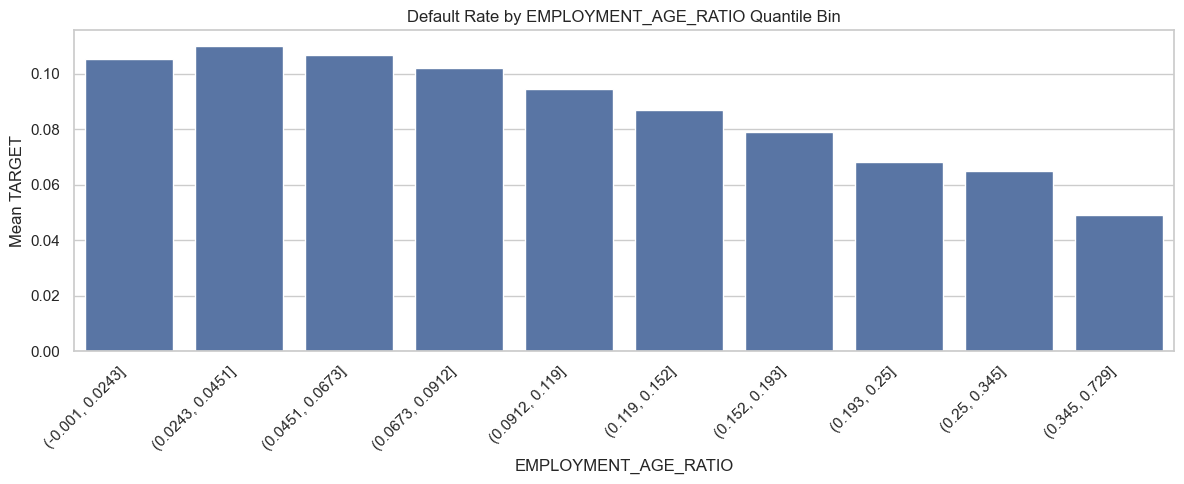

In [82]:
for col in ratio_cols:
    plot_default_rate_by_bin(train, col, q=10, filename=f"default_rate_by_{col.lower()}_bin.png")

### 8. Quick Categorical Scan

In [83]:
cat_summary = pd.DataFrame({
    "column": categorical_cols,
    "n_unique": [train[col].nunique(dropna=False) for col in categorical_cols],
    "missing_pct": [train[col].isnull().mean() * 100 for col in categorical_cols],
}).sort_values(["n_unique", "missing_pct"], ascending=[True, False])

display(cat_summary.head(20))

,column,n_unique,missing_pct
0,NAME_CONTRACT_TYPE,2,0.0000
2,FLAG_OWN_CAR,2,0.0000
3,FLAG_OWN_REALTY,2,0.0000
15,EMERGENCYSTATE_MODE,3,47.3983
1,CODE_GENDER,3,0.0000
13,HOUSETYPE_MODE,4,50.1761
12,FONDKAPREMONT_MODE,5,68.3862
6,NAME_EDUCATION_TYPE,5,0.0000
7,NAME_FAMILY_STATUS,6,0.0000
8,NAME_HOUSING_TYPE,6,0.0000


In [84]:
important_cat_cols = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
]

existing_important_cat_cols = [col for col in important_cat_cols if col in train.columns]
print(existing_important_cat_cols)

for col in existing_important_cat_cols:
    print(f"\n===== {col} =====")
    display(train[col].fillna("MISSING").value_counts(dropna=False).head(10))

['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']

===== NAME_CONTRACT_TYPE =====


NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64


===== CODE_GENDER =====


CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64


===== NAME_INCOME_TYPE =====


...

NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64


===== NAME_HOUSING_TYPE =====


NAME_HOUSING_TYPE
House / apartment      272868
With parents            14840
Municipal apartment     11183
Rented apartment         4881
Office apartment         2617
Co-op apartment          1122
Name: count, dtype: int64


===== OCCUPATION_TYPE =====


OCCUPATION_TYPE
MISSING                  96391
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Name: count, dtype: int64

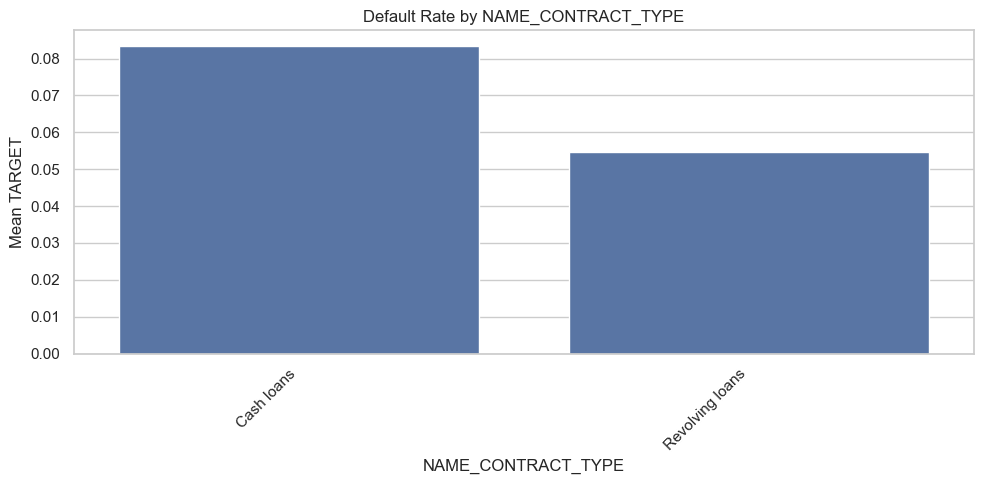

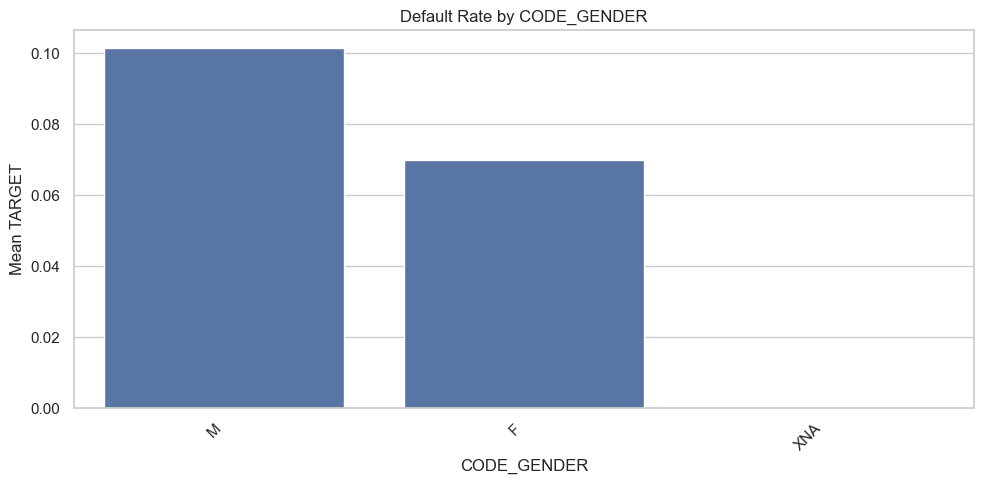

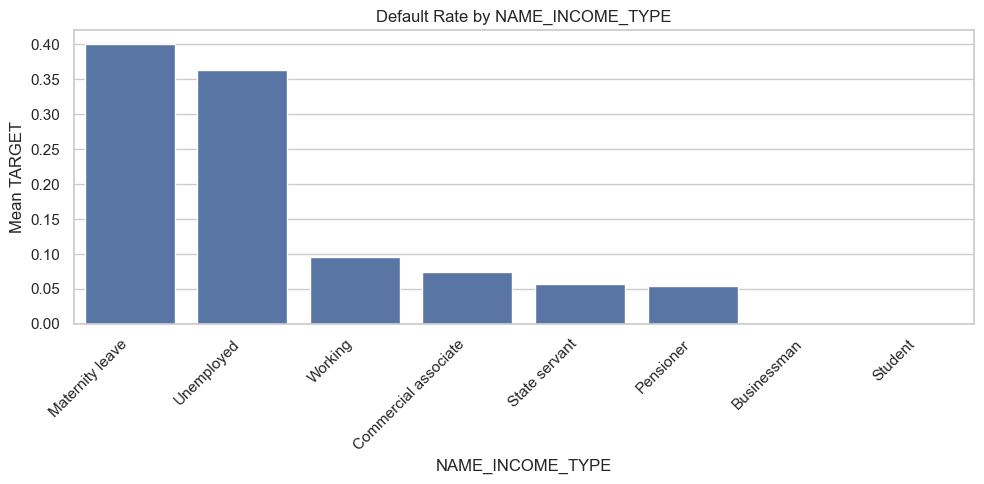

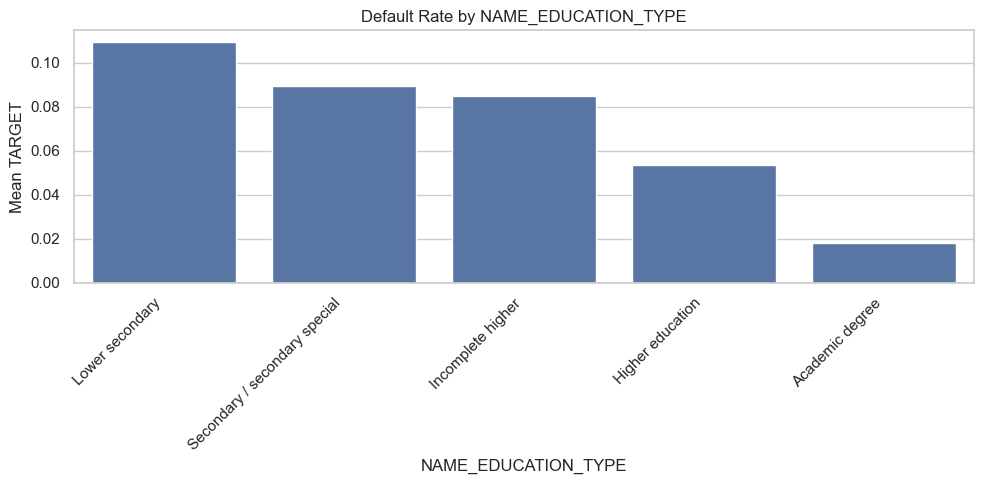

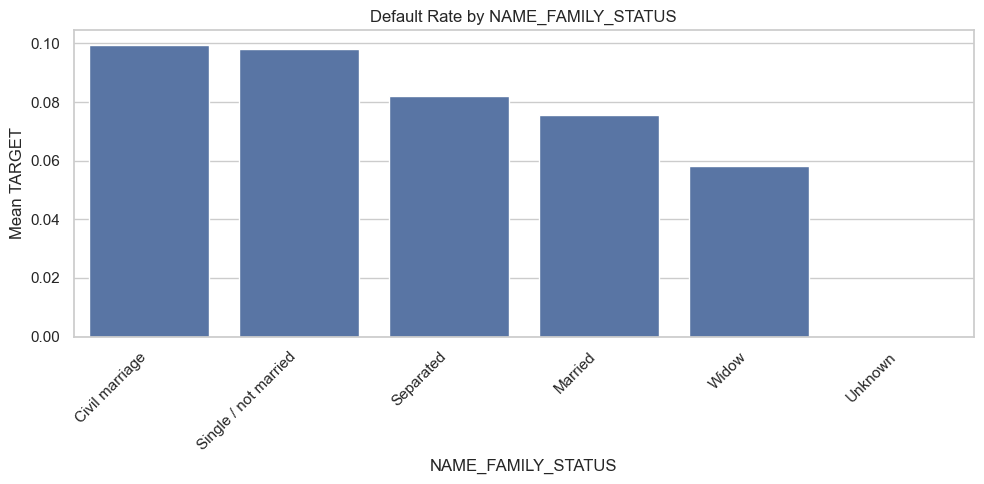

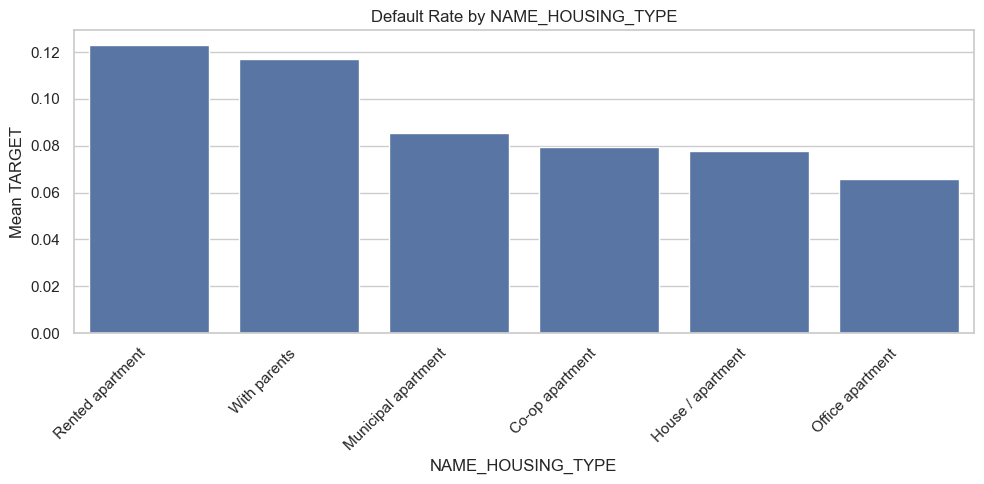

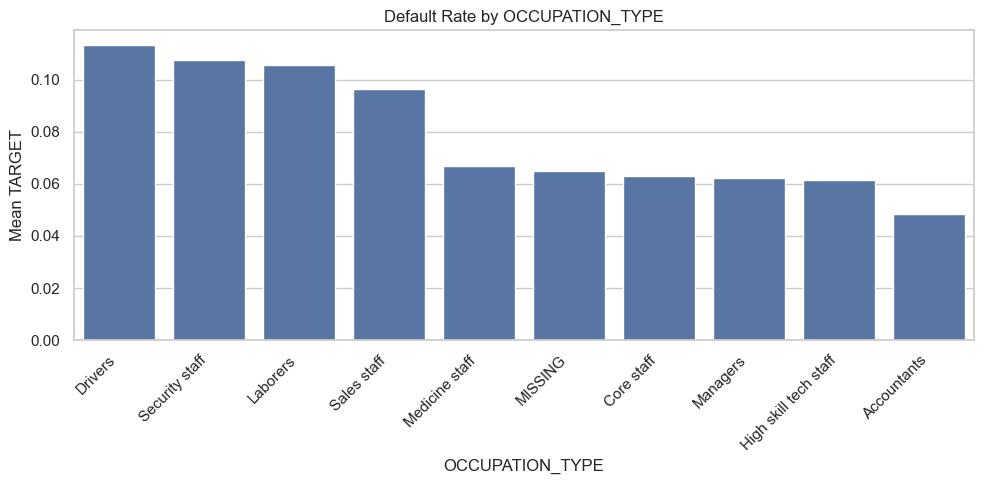

In [85]:
for col in existing_important_cat_cols:
    plot_default_rate_by_category(train, col, top_n=10, filename=f"default_rate_by_{col.lower()}.png")

### 9. Train vs Test Consistency Check

In [86]:
compare_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
]

compare_summary = []
for col in compare_cols:
    compare_summary.append({
        "column": col,
        "train_mean": train[col].mean(),
        "test_mean": test[col].mean(),
        "train_median": train[col].median(),
        "test_median": test[col].median(),
        "train_missing_pct": train[col].isnull().mean() * 100,
        "test_missing_pct": test[col].isnull().mean() * 100,
    })

compare_summary_df = pd.DataFrame(compare_summary)
display(compare_summary_df)

,column,train_mean,test_mean,train_median,test_median,train_missing_pct,test_missing_pct
0,AMT_INCOME_TOTAL,"168,797.9193","178,431.8059","147,150.0000","157,500.0000",0.0000,0.0000
1,AMT_CREDIT,"599,025.9997","516,740.4356","513,531.0000","450,000.0000",0.0000,0.0000
2,AMT_ANNUITY,"27,108.5739","29,426.2402","24,903.0000","26,199.0000",0.0039,0.0492
3,DAYS_BIRTH,"-16,036.9951","-16,068.0846","-15,750.0000","-15,785.0000",0.0000,0.0000
4,DAYS_EMPLOYED,"63,815.0459","67,485.3663","-1,213.0000","-1,293.0000",0.0000,0.0000


In [87]:
for col in ["NAME_CONTRACT_TYPE", "CODE_GENDER", "NAME_INCOME_TYPE"]:
    if col in train.columns and col in test.columns:
        print(f"\n===== {col} =====")
        print("Train categories:", sorted(train[col].dropna().astype(str).unique().tolist())[:20])
        print("Test categories :", sorted(test[col].dropna().astype(str).unique().tolist())[:20])


===== NAME_CONTRACT_TYPE =====
Train categories: ['Cash loans', 'Revolving loans']
Test categories : ['Cash loans', 'Revolving loans']

===== CODE_GENDER =====
Train categories: ['F', 'M', 'XNA']
Test categories : ['F', 'M']

===== NAME_INCOME_TYPE =====
Train categories: ['Businessman', 'Commercial associate', 'Maternity leave', 'Pensioner', 'State servant', 'Student', 'Unemployed', 'Working']
Test categories : ['Businessman', 'Commercial associate', 'Pensioner', 'State servant', 'Student', 'Unemployed', 'Working']


### 10. Notebook Summary

In [88]:
top_missing_cols = missing_train.head(10)["column"].tolist()

summary_lines = [
    "# Main Table EDA Summary",
    "",
    "## Dataset",
    f"- Train shape: {train.shape}",
    f"- Test shape: {test.shape}",
    "",
    "## Target",
    f"- TARGET=0 count: {int(target_counts.get(0, 0)):,}",
    f"- TARGET=1 count: {int(target_counts.get(1, 0)):,}",
    f"- TARGET=1 proportion: {target_props.get(1, 0):.4f}",
    "",
    "## Missing Values",
    "- Top 10 columns by missing percentage:",
]

for col in top_missing_cols:
    pct = missing_train.loc[missing_train["column"] == col, "missing_pct"].values[0]
    summary_lines.append(f"  - {col}: {pct:.2f}%")

summary_lines += [
    "",
    "## Key Findings",
    "- The target is imbalanced, so accuracy is not the right metric.",
    "- Several columns have substantial missingness and should be handled carefully.",
    "- Core financial variables are strongly skewed and contain outliers.",
    "- DAYS_EMPLOYED contains the anomaly value 365243 and should be treated separately.",
    "- Ratio features look more meaningful than some raw variables.",
    "",
    "## Candidate Features",
    "- AMT_INCOME_TOTAL",
    "- AMT_CREDIT",
    "- AMT_ANNUITY",
    "- AGE_YEARS",
    "- DAYS_EMPLOYED_CLEAN",
    "- DAYS_EMPLOYED_ANOM",
    "- INCOME_CREDIT_RATIO",
    "- ANNUITY_INCOME_RATIO",
    "- CREDIT_GOODS_RATIO",
    "- EMPLOYMENT_AGE_RATIO",
]

In [89]:
report_path = REPORT_DIR / "main_table_eda.md"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(summary_lines))

print("Report saved to:", report_path)
print("\n".join(summary_lines))

Report saved to: c:\Coding\Home-Credit-Default-Risk\outputs\reports\main_table_eda.md
# Main Table EDA Summary

## Dataset
- Train shape: (307511, 131)
- Test shape: (48744, 130)

## Target
- TARGET=0 count: 282,686
- TARGET=1 count: 24,825
- TARGET=1 proportion: 0.0807

## Missing Values
- Top 10 columns by missing percentage:
  - COMMONAREA_MEDI: 69.87%
  - COMMONAREA_AVG: 69.87%
  - COMMONAREA_MODE: 69.87%
  - NONLIVINGAPARTMENTS_MODE: 69.43%
  - NONLIVINGAPARTMENTS_AVG: 69.43%
  - NONLIVINGAPARTMENTS_MEDI: 69.43%
  - FONDKAPREMONT_MODE: 68.39%
  - LIVINGAPARTMENTS_MODE: 68.35%
  - LIVINGAPARTMENTS_AVG: 68.35%
  - LIVINGAPARTMENTS_MEDI: 68.35%

## Key Findings
- The target is imbalanced, so accuracy is not the right metric.
- Several columns have substantial missingness and should be handled carefully.
- Core financial variables are strongly skewed and contain outliers.
- DAYS_EMPLOYED contains the anomaly value 365243 and should be treated separately.
- Ratio features look more mea